In [1]:
import chipwhisperer as cw
import chipwhisperer.common.results.glitch as glitch
import numpy as np
import time

# --- USER CONFIGURATION ---
# *** IMPORTANT:BITSTREAM PATH ***
BITSTREAM_FILEPATH = r'/home/sareeta/chipwhisperer/firmware/fpgas/aes/vivado/cw305_aes.runs/impl_100t/cw305_top.bit'

# Set a fixed key and plaintext for consistent testing
KEY = bytearray([0x2B, 0x7E, 0x15, 0x16, 0x28, 0xAE, 0xD2, 0xA6, 0xAB, 0xF7, 0x15, 0x88, 0x09, 0xCF, 0x4F, 0x3C])
PLAINTEXT = bytearray([0x5C, 0x69, 0x2F, 0x91, 0x03, 0xB2, 0x30, 0x29, 0x14, 0xD7, 0xE5, 0x55, 0xE4, 0xDC, 0xEE, 0x49])
EXPECTED_CIPHERTEXT = bytearray([0x06, 0xF3, 0x6A, 0x65, 0xE8, 0xA9, 0x9F, 0xF8, 0x90, 0x7B, 0x2E, 0x5E, 0x5D, 0xDD, 0x77, 0xDE])

#expected=06f36a65e8a99ff8907b2e5e5ddd77de
#outputou=06f36a65e8a99ff8907b2e5e5ddd77de
          #04f36a65e8a99fd8907b0e5e5ddd77de
#0.88targ=04f36a65e8a99ff8907b2e5e5ddd77de
#0.86targ=04f36a65e8a99ff8907b2e5e5ddd77de
#0.87targ=04f36a65e8a99dd8907b0e5e5ddd57de
#0.8799999=04f36a65e8a99ff8907b2e5e5ddd77de
#0.86targ=04d14845c8899dd890590c5c5ddd54dc
# Attack Parameters

NUM_GLITCH_ATTEMPTS = 500 # Number of times to try glitching
NUM_NORMAL_TRACES = 10000 # Number of traces without glitch for comparison
#VCC_INT_TARGET = 0.87
# --- CONNECTION ---
scope = cw.scope()
target = cw.target(scope, cw.targets.CW305, bsfile=BITSTREAM_FILEPATH, force=True)

(ChipWhisperer NAEUSB WARNING|File naeusb.py:826) Your firmware (0.53.0) is outdated - latest is 0.54.0 See https://chipwhisperer.readthedocs.io/en/latest/firmware.html for more information
(ChipWhisperer Target WARNING|File CW305.py:510) FPGA Bitstream not configured or 'C:\Users\sbista\ChipWhisperer\chipwhisperer\firmware\fpgas\aes\vivado_cw\cw305_aes.runs\impl_100t\cw305_top.bit' not a file.
(ChipWhisperer Target WARNING|File CW305.py:591) Using default Verilog defines (/home/sareeta/chipwhisperer/software/chipwhisperer/hardware/firmware/cw305/cw305_aes_defines.v); if this is not what you want, provide them via the defines_files argument


In [2]:
print(f"Target VCC-INT set to: {target.vccint_get()}V")

# Setup PLL1 on CW305 (assuming 10MHz external clock is provided by CW-Lite)
target.pll.pll_outfreq_set(10E6, 1) 
target.pll.pll_enable_set(True)
target.pll.pll_outenable_set(True, 1)

# --- CONFIGURE CW-LITE SCOPE FOR POWER TRACING ---
# Use the clock generated by the CW305 (EXTCLK) as the ADC clock source
scope.default_setup()
scope.clock.adc_src = "extclk_x4" # Use 4x the target clock for sampling
scope.adc.samples = 400 # Number of samples to capture per trace
scope.adc.offset = 0
scope.gain.gain = 25
scope.adc.presamples = 0
scope.adc.basic_mode = "falling_edge"
scope.trigger.triggers = 'tio4' # FPGA trigger pin TIO4 is used to arm the scope/glitch
scope.io.tio1 = "serial_tx"
scope.io.tio2 = "serial_rx"
scope.io.tio3 = "high_z" # Not used
scope.io.tio4 = "high_z" # Used for trigger, set by FPGA
import time
for i in range(5):
    scope.clock.reset_adc()
    time.sleep(1)
    if scope.clock.adc_locked:
        break 
assert (scope.clock.adc_locked), "ADC failed to lock"

Target VCC-INT set to: 1.0V
scope.gain.mode                          changed from low                       to high                     
scope.gain.gain                          changed from 0                         to 30                       
scope.gain.db                            changed from 5.5                       to 24.8359375               
scope.adc.basic_mode                     changed from low                       to rising_edge              
scope.adc.samples                        changed from 24400                     to 5000                     
scope.adc.trig_count                     changed from 513337931                 to 529936503                
scope.clock.adc_src                      changed from clkgen_x1                 to clkgen_x4                
scope.clock.adc_freq                     changed from 96000000                  to 29538459                 
scope.clock.adc_rate                     changed from 96000000.0                to 29538459.0       

In [3]:
def run_aes(target, plaintext, key):
    target.set_key(key)
    target.simpleserial_write('p', plaintext)
    # The target.go() is handled by simpleserial_write for the CW305 target
    
    # Read the output from the target
    try:
        response = target.simpleserial_read('r', 16)
        if len(response) == 16:
            return response, True
        else:
            return None, False
    except Exception as e:
        print(f"Target read error: {e}")
        return None, False

In [4]:

for i in range(10):
    scope.arm()
    out, ok = run_aes(target, PLAINTEXT, KEY)
    
    if scope.capture():
        print("Timeout – no trigger seen")
        continue


    if ok and out != EXPECTED_CIPHERTEXT:
        print("REAL GLITCH FAULT FOUND:", out.hex())
        break
    else:
        print("normal",out.hex())


normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de


In [5]:
## --- 2. CAPTURE NORMAL TRACES ---
print("\n--- Collecting Normal Traces ---")
# Storage for the normal traces
normal_traces = []

for i in range(NUM_NORMAL_TRACES):
    scope.arm()
    output, success = run_aes(target, PLAINTEXT, KEY)
    
    if scope.capture():
        print(f"Timeout occurred on trace {i}")
        continue

    trace = scope.get_last_trace()
    normal_traces.append(trace)
    
    # Verify the output is the expected ciphertext
    #if output == EXPECTED_CIPHERTEXT:
        #print(f"Trace {i}: Success, Output: {output.hex()}")
    #else:
        #print(f"Trace {i}: FAIL, Output: {output.hex() if output else 'N/A'}")

    if output != EXPECTED_CIPHERTEXT:
        print(f"Trace {i}: FAIL, Output: {output.hex() if output else 'N/A'}")
        
print(f"Baseline trace collection complete. Collected {len(normal_traces)} good traces.")



--- Collecting Normal Traces ---
Baseline trace collection complete. Collected 10000 good traces.


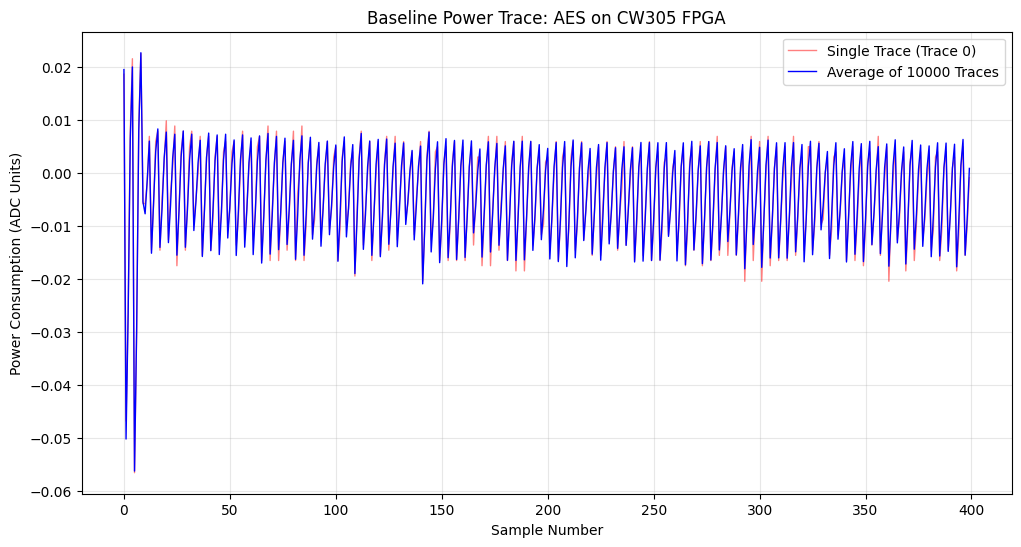

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure your normal_traces list has data
if not normal_traces:
    print("Error: No traces were collected. Run the 'Normal Trace Collection' loop first.")
else:
    # --- PLOT SETUP ---
    
    # 1. Get the first trace as a baseline
    first_trace = np.array(normal_traces[0])
    
    # 2. Get the average of all collected traces (provides a cleaner view)
    average_trace = np.average(normal_traces, axis=0)
    
    # --- PLOTTING ---
    plt.figure(figsize=(12, 6))
    
    # Plot the first collected trace
    plt.plot(first_trace, label="Single Trace (Trace 0)", color='red', alpha=0.5,linewidth=1)
    
    # Plot the average trace
    plt.plot(average_trace, label=f"Average of {len(normal_traces)} Traces", color='blue', linewidth=1)
    
    plt.title("Baseline Power Trace: AES on CW305 FPGA")
    plt.xlabel("Sample Number")
    plt.ylabel("Power Consumption (ADC Units)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [6]:
# Enable glitch path
scope.io.glitch_lp = True     
scope.io.glitch_hp = True
scope.glitch.repeat = 1
scope.glitch.trigger_src = 'ext_single'  
scope.glitch.width  = 4
scope.glitch.offset = -20.0
for i in range(10):
    scope.arm()
    out, ok = run_aes(target, PLAINTEXT, KEY)
    
    if scope.capture():
        print("Timeout – no trigger seen")
        continue
    if ok and out != EXPECTED_CIPHERTEXT:
        print("REAL GLITCH FAULT FOUND:", out.hex())
    else:
        print("normal",out.hex())

normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de


In [7]:

for i in range(1000):
    scope.arm()
    out, ok = run_aes(target, PLAINTEXT, KEY)
    
    if scope.capture():
        print("Timeout – no trigger seen")
        continue
    if ok and out != EXPECTED_CIPHERTEXT:
        print("REAL GLITCH FAULT FOUND:", out.hex())
    else:
        print("normal",out.hex())

normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de
normal 06f36a65e8a99ff8907b2e5e5ddd77de


In [8]:
def diff_bytes(a, b):
    return sum(x != y for x, y in zip(a, b))
N = 10000
faults = 0
hist = {}
for i in range(N):
    scope.arm()
    out, ok = run_aes(target, PLAINTEXT, KEY)
    if scope.capture() or (not ok) or out is None:
        continue

    d = diff_bytes(out, EXPECTED_CIPHERTEXT)
    hist[d] = hist.get(d, 0) + 1
    if d != 0:
        faults += 1
print("Fault rate:", faults / N)
print("Diff-bytes histogram:", dict(sorted(hist.items())))

Fault rate: 0.0
Diff-bytes histogram: {0: 10000}


In [33]:
from collections import Counter

pos_ctr = Counter()

for i in range(N):
    scope.arm()
    out, ok = run_aes(target, PLAINTEXT, KEY)
    if scope.capture() or (not ok) or out is None:
        continue
    if out == EXPECTED_CIPHERTEXT:
        continue
    for idx, (a,b) in enumerate(zip(out, EXPECTED_CIPHERTEXT)):
        if a != b:
            pos_ctr[idx] += 1

print("Byte position fault counts (0..15):")
print(dict(sorted(pos_ctr.items())))


Byte position fault counts (0..15):
{0: 154, 1: 117, 2: 132, 3: 155, 4: 137, 5: 142, 6: 125, 7: 135, 9: 124, 10: 128, 11: 135, 12: 79, 13: 65, 14: 147, 15: 144}


In [34]:
mask_ctr = Counter()

for i in range(N):
    scope.arm()
    out, ok = run_aes(target, PLAINTEXT, KEY)
    if scope.capture() or (not ok) or out is None:
        continue
    if out == bytes(EXPECTED_CIPHERTEXT):
        continue
    masks = bytes([x ^ y for x,y in zip(out, EXPECTED_CIPHERTEXT)])
    mask_ctr[masks.hex()] += 1

print("Top 10 XOR masks:")
for m,c in mask_ctr.most_common(10):
    print(c, m)


Top 10 XOR masks:
120 00000000000000200000000000000000
64 00000000000003000000000000000000
59 02000000000000000023000000000000
55 00002200000000000000000200000000
51 00230000000000000000220000000000
48 00000000200000000000000000010002
37 00220000000000000000220000000000
35 00000020000000000000000001000000
35 02000000000000000000000000000000
34 00000000002000000000000000002300


In [12]:
for off in np.linspace(-40, 40, 90):
    scope.glitch.offset = off
    scope.arm()
    out, ok = run_aes(target, PLAINTEXT, KEY)
    scope.capture()
    if ok and out != EXPECTED_CIPHERTEXT:
        print("FAULT at offset", off, out.hex())


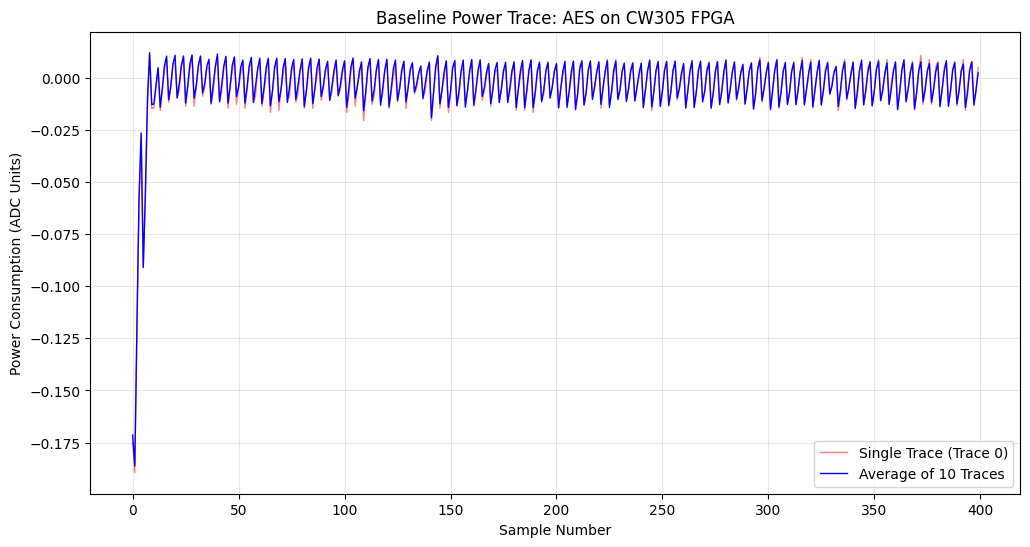

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure your normal_traces list has data
if not normal_traces:
    print("Error: No traces were collected. Run the 'Normal Trace Collection' loop first.")
else:
    # --- PLOT SETUP ---
    
    # 1. Get the first trace as a baseline
    first_trace = np.array(normal_traces[0])
    
    # 2. Get the average of all collected traces (provides a cleaner view)
    average_trace = np.average(normal_traces, axis=0)
    
    # --- PLOTTING ---
    plt.figure(figsize=(12, 6))
    
    # Plot the first collected trace
    plt.plot(first_trace, label="Single Trace (Trace 0)", color='red', alpha=0.5,linewidth=1)
    
    # Plot the average trace
    plt.plot(average_trace, label=f"Average of {len(normal_traces)} Traces", color='blue', linewidth=1)
    
    plt.title("Baseline Power Trace: AES on CW305 FPGA")
    plt.xlabel("Sample Number")
    plt.ylabel("Power Consumption (ADC Units)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [7]:
from Crypto.Cipher import AES
exp_sw = AES.new(KEY, AES.MODE_ECB).encrypt(PLAINTEXT).hex()
print("SW expected:", exp_sw)


SW expected: 06f36a65e8a99ff8907b2e5e5ddd77de


In [19]:
for v in [0.90, 0.88, 0.87, 0.86]:
    target.vccint_set(v)
    time.sleep(0.2)
    time.sleep(0.1)
    print("\nTesting VCC:", v)

    for i in range(10):
        scope.arm()
        out, ok = run_aes(target, PLAINTEXT, KEY)
        scope.capture()
        print(i, ok, out.hex() if out else None)



Testing VCC: 0.9
0 True 06f36a65e8a99ff8907b2e5e5ddd77de
1 True 06f36a65e8a99ff8907b2e5e5ddd77de
2 True 06f36a65e8a99ff8907b2e5e5ddd77de
3 True 06f36a65e8a99ff8907b2e5e5ddd77de
4 True 06f36a65e8a99ff8907b2e5e5ddd77de
5 True 06f36a65e8a99ff8907b2e5e5ddd77de
6 True 06f36a65e8a99ff8907b2e5e5ddd77de
7 True 06f36a65e8a99ff8907b2e5e5ddd77de
8 True 06f36a65e8a99ff8907b2e5e5ddd77de
9 True 06f36a65e8a99ff8907b2e5e5ddd77de

Testing VCC: 0.88
0 True 06f36a45e8a99fd8907b2e5e5ddd77de
1 True 04d16a65e8899ff8907b0c5e5ddd55de
2 True 06f34865e8a99df8907b0c5e5ddd77de
3 True 04f36a65e8899ff890592e5e5ddd55dc
4 True 04d16a65e8899ff8907b0c5e5ddd55de
5 True 04f36a65c8a99ff8907b2e5e5ddd77de
6 True 04f36a65c8a99ff8907b2e5e5ddd77dc
7 True 04f36a65e8899ff890592e5e5ddd57dc
8 True 06f36a45e8a99ff8907b2e5e5ddd77de
9 True 06f36a45e8a99fd8907b2e5c5ddd77de

Testing VCC: 0.87
0 True 04f36a45c8a99ff8905b2e5e5ddd77dc
1 True 04f36a45c8a99ff8905b2e5e5ddd77dc
2 True 04f36a45c8a99fd8907b2e5e5cdd77dc
3 True 04f36a65c8899ff89

In [8]:
target.vccint_set(1.0)
time.sleep(0.2)

# HARD disable glitch
scope.glitch.repeat = 1
scope.io.glitch_lp = False
scope.io.glitch_hp = False

# Sanity check
for i in range(10):
    scope.arm()
    out, ok = run_aes(target, PLAINTEXT, KEY)
    scope.capture()
    assert out == EXPECTED_CIPHERTEXT


In [9]:
# Enable glitch path
scope.io.glitch_lp = True     # CW305 uses LP glitch
scope.io.glitch_hp = False

scope.glitch.repeat = 1
scope.glitch.trigger_src = 'ext_single'  # standard
target.vccint_set(1.0)   # NOT 0.87, NOT 0.86
time.sleep(0.1)
scope.glitch.width  = 2.0     # small
scope.glitch.offset = 20.0    # early, but not extreme
for i in range(10):
    scope.arm()
    out, ok = run_aes(target, PLAINTEXT, KEY)

    if scope.capture():
        continue

    if ok and out != EXPECTED_CIPHERTEXT:
        print("REAL GLITCH FAULT FOUND:", out.hex())
        break
    else:
        print("normal")



normal
normal
normal
normal
normal
normal
normal
normal
normal
normal


In [27]:
for off in np.linspace(15, 49, 90):
    scope.glitch.offset = off
    scope.arm()
    out, ok = run_aes(target, PLAINTEXT, KEY)
    scope.capture()
    if ok and out != EXPECTED_CIPHERTEXT:
        print("FAULT at offset", off, out.hex())


In [28]:
def diff_bytes(a, b):
    return sum(x != y for x, y in zip(a, b))

N = 1000
faults = 0
hist = {}

for i in range(N):
    scope.arm()
    out, ok = run_aes(target, PLAINTEXT, KEY)
    if scope.capture() or (not ok) or out is None:
        continue

    d = diff_bytes(out, EXPECTED_CIPHERTEXT)
    hist[d] = hist.get(d, 0) + 1
    if d != 0:
        faults += 1

print("Fault rate:", faults / N)
print("Diff-bytes histogram:", dict(sorted(hist.items())))


Fault rate: 0.0
Diff-bytes histogram: {0: 1000}


In [10]:
scope.glitch.width = 2.0
scope.glitch.repeat = 1

for off in np.linspace(-49, 49, 31):  # 15.0 to 30.0 step 0.5
    scope.glitch.offset = float(off)

    # run 50 trials at each offset
    faults = 0
    one_or_four = 0
    for i in range(50):
        scope.arm()
        out, ok = run_aes(target, PLAINTEXT, KEY)
        if scope.capture() or (not ok) or out is None:
            continue
        d = diff_bytes(out, EXPECTED_CIPHERTEXT)
        if d != 0:
            faults += 1
        if d in (1,2,4):
            one_or_four += 1

    print(f"offset={off:.1f} faults={faults}/50, small_faults={one_or_four}/50")


NameError: name 'diff_bytes' is not defined

In [ ]:
scope.glitch.width = 2.0
for off in [-40, -20, -10, -5, 1, 5, 10, 20, 30, 40]:
    scope.glitch.offset = off
    faults = 0
    total = 0
    for i in range(50):
        scope.arm()
        out, ok = run_aes(target, PLAINTEXT, KEY)
        if scope.capture() or (not ok) or out is None:
            continue
        total += 1
        if out != EXPECTED_CIPHERTEXT:
            faults += 1
    print(f"off={off:>5} faults={faults}/{total}")


In [13]:
print("repeat:", scope.glitch.repeat)
print("trigger_src:", scope.glitch.trigger_src)
print("width:", scope.glitch.width, "offset:", scope.glitch.offset)


repeat: 1
trigger_src: ext_single
width: 1.953125 offset: 39.84375


In [14]:
print("glitch_lp:", scope.io.glitch_lp)
print("glitch_hp:", scope.io.glitch_hp)
print(scope.io)   # shows full IO status


glitch_lp: True
glitch_hp: False
tio1         = serial_tx
tio2         = serial_rx
tio3         = high_z
tio4         = high_z
pdid         = high_z
pdic         = high_z
nrst         = high_z
glitch_hp    = False
glitch_lp    = True
extclk_src   = hs1
hs2          = clkgen
target_pwr   = True
tio_states   = (1, 0, 0, 0)
cdc_settings = bytearray(b'\x00\x00\x00\x00')



In [15]:
# If your target supports readback (not always):
try:
    print("VCCINT read:", target.vccint_get())
except:
    print("No vccint_get() available. Confirm with DMM if needed.")


VCCINT read: 1.0


In [16]:
print(scope.io.glitch_lp, scope.glitch.repeat, scope.glitch.trigger_src, scope.glitch.width, scope.glitch.offset)


True 1 ext_single 1.953125 39.84375


attempts=200  collected_faults=191  ok_reads=200  normals=9  faults=191  timeouts=0

--- Fault trace collection summary ---
attempts=318, collected_fault_traces=300
ok_reads=318, normals=18, faults=300, timeouts=0


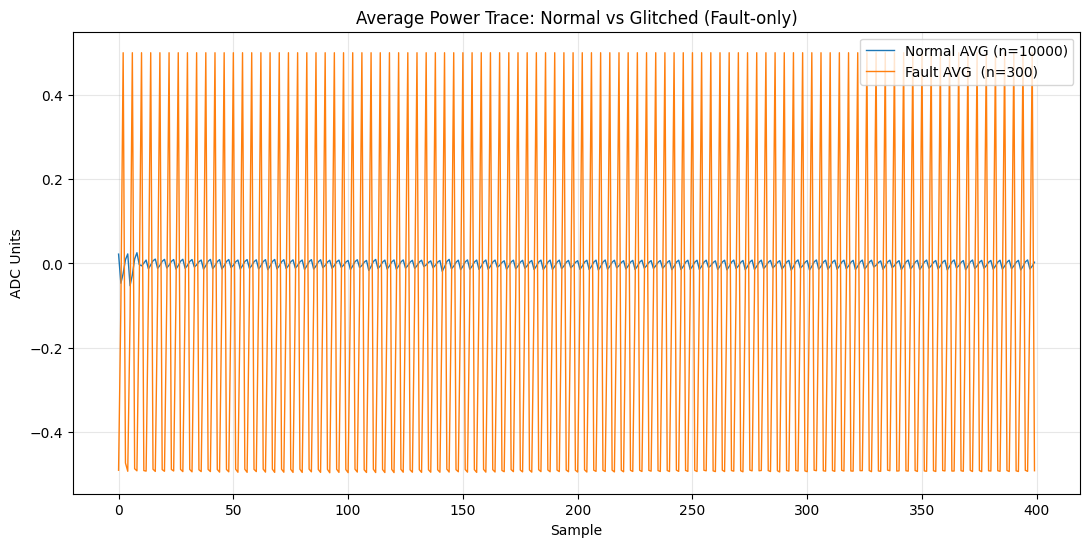

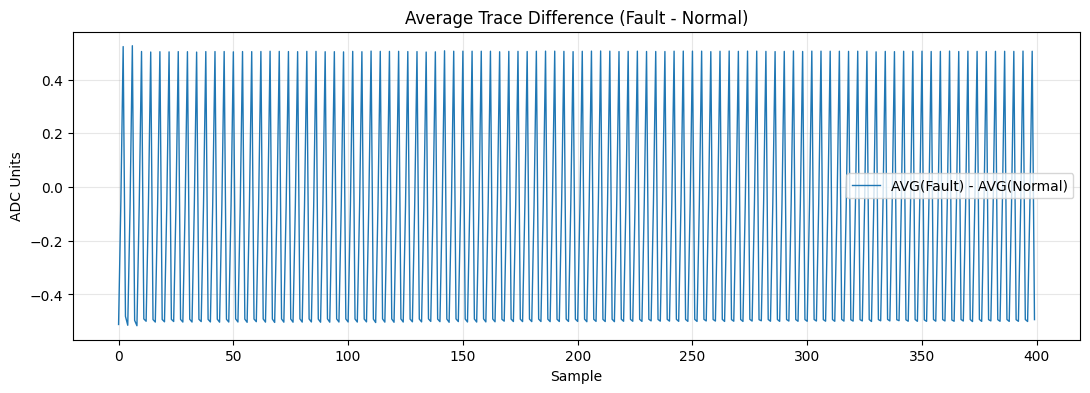

In [35]:
import numpy as np
import matplotlib.pyplot as plt

EXPECTED = bytes(EXPECTED_CIPHERTEXT)

# ---- collect fault-only traces ----
def collect_fault_traces(num_fault_traces=300, max_attempts=5000, verbose_every=200):
    fault_traces = []
    fault_outputs = []
    attempts = 0
    timeouts = 0
    ok_reads = 0
    normals = 0
    faults = 0

    while (len(fault_traces) < num_fault_traces) and (attempts < max_attempts):
        attempts += 1
        scope.arm()
        out, ok = run_aes(target, PLAINTEXT, KEY)

        if scope.capture():
            timeouts += 1
            continue

        if (not ok) or (out is None) or (len(out) != 16):
            continue

        ok_reads += 1

        if out == EXPECTED:
            normals += 1
            continue

        # fault
        faults += 1
        fault_traces.append(np.array(scope.get_last_trace(), dtype=np.float32))
        fault_outputs.append(bytes(out))

        if verbose_every and (attempts % verbose_every == 0):
            print(f"attempts={attempts}  collected_faults={len(fault_traces)}  "
                  f"ok_reads={ok_reads}  normals={normals}  faults={faults}  timeouts={timeouts}")

    print("\n--- Fault trace collection summary ---")
    print(f"attempts={attempts}, collected_fault_traces={len(fault_traces)}")
    print(f"ok_reads={ok_reads}, normals={normals}, faults={faults}, timeouts={timeouts}")
    return fault_traces, fault_outputs

# Choose how many fault traces you want to average (100–1000 is typical)
fault_traces, fault_outputs = collect_fault_traces(num_fault_traces=300, max_attempts=8000)

# ---- compute averages ----
normal_avg = np.mean(np.asarray(normal_traces, dtype=np.float32), axis=0)

fault_avg  = np.mean(np.asarray(fault_traces, dtype=np.float32), axis=0)

# ---- plot average normal vs average fault ----
plt.figure(figsize=(13, 6))
plt.plot(normal_avg, label=f"Normal AVG (n={len(normal_traces)})", linewidth=1)
plt.plot(fault_avg,  label=f"Fault AVG  (n={len(fault_traces)})", linewidth=1)

plt.title("Average Power Trace: Normal vs Glitched (Fault-only)")
plt.xlabel("Sample")
plt.ylabel("ADC Units")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# ---- plot difference (fault_avg - normal_avg) ----
plt.figure(figsize=(13, 4))
plt.plot(fault_avg - normal_avg, label="AVG(Fault) - AVG(Normal)", linewidth=1)
plt.title("Average Trace Difference (Fault - Normal)")
plt.xlabel("Sample")
plt.ylabel("ADC Units")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


i=500/10000  collected=500  normals=25  faults=475  timeouts=0  bad_reads=0
i=1000/10000  collected=1000  normals=46  faults=954  timeouts=0  bad_reads=0
i=1500/10000  collected=1500  normals=78  faults=1422  timeouts=0  bad_reads=0
i=2000/10000  collected=2000  normals=98  faults=1902  timeouts=0  bad_reads=0
i=2500/10000  collected=2500  normals=124  faults=2376  timeouts=0  bad_reads=0
i=3000/10000  collected=3000  normals=150  faults=2850  timeouts=0  bad_reads=0
i=3500/10000  collected=3500  normals=170  faults=3330  timeouts=0  bad_reads=0
i=4000/10000  collected=4000  normals=205  faults=3795  timeouts=0  bad_reads=0
i=4500/10000  collected=4500  normals=239  faults=4261  timeouts=0  bad_reads=0
i=5000/10000  collected=5000  normals=267  faults=4733  timeouts=0  bad_reads=0
i=5500/10000  collected=5500  normals=302  faults=5198  timeouts=0  bad_reads=0
i=6000/10000  collected=6000  normals=333  faults=5667  timeouts=0  bad_reads=0
i=6500/10000  collected=6500  normals=362  fault

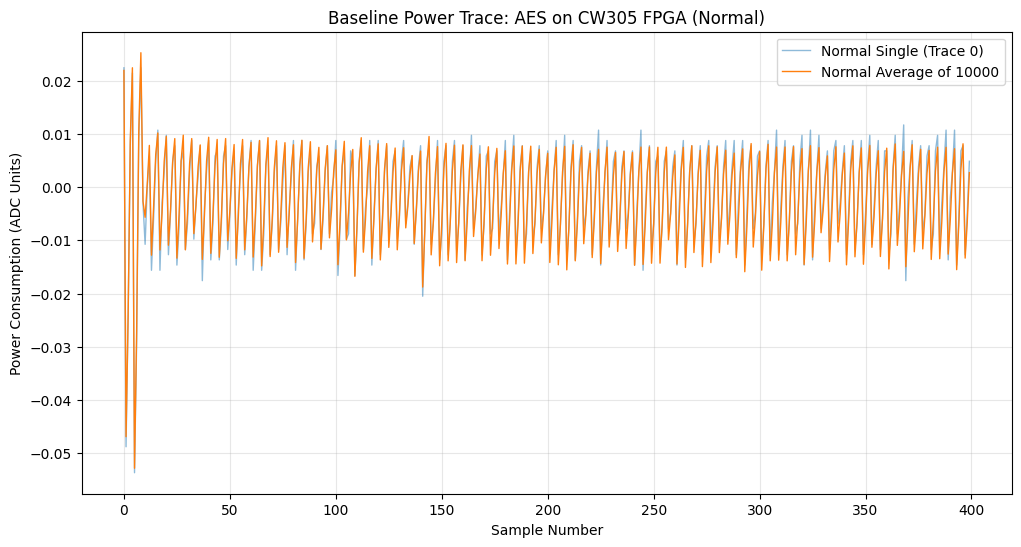

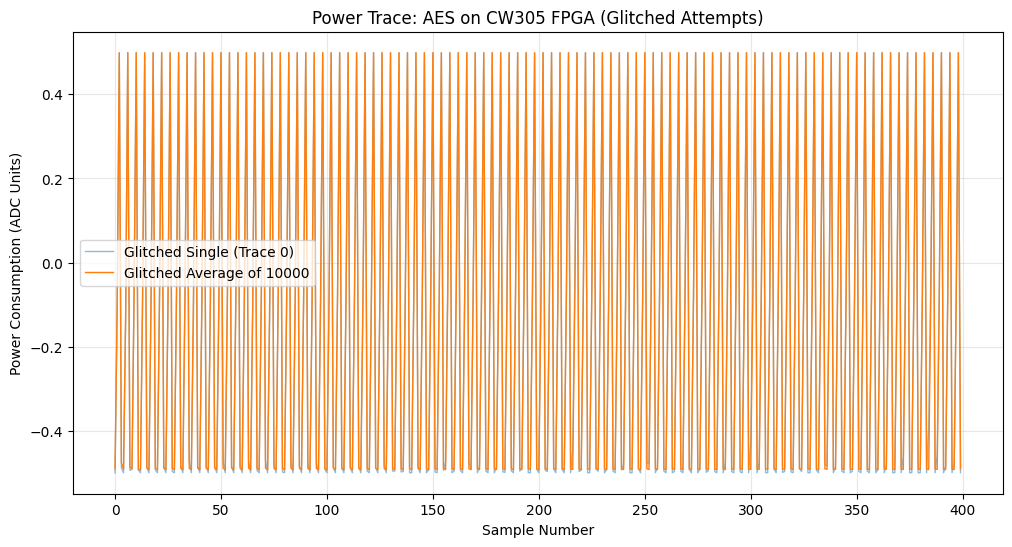

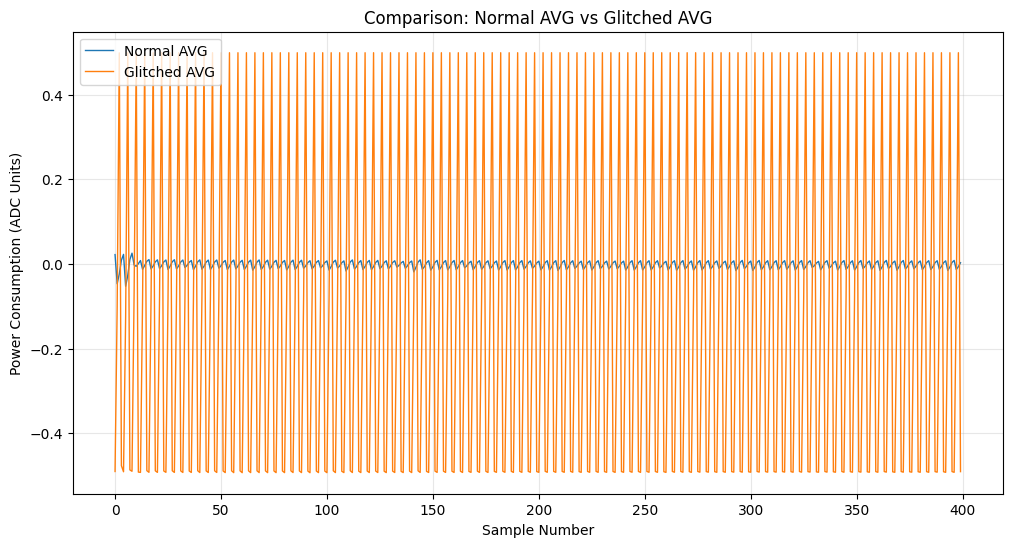

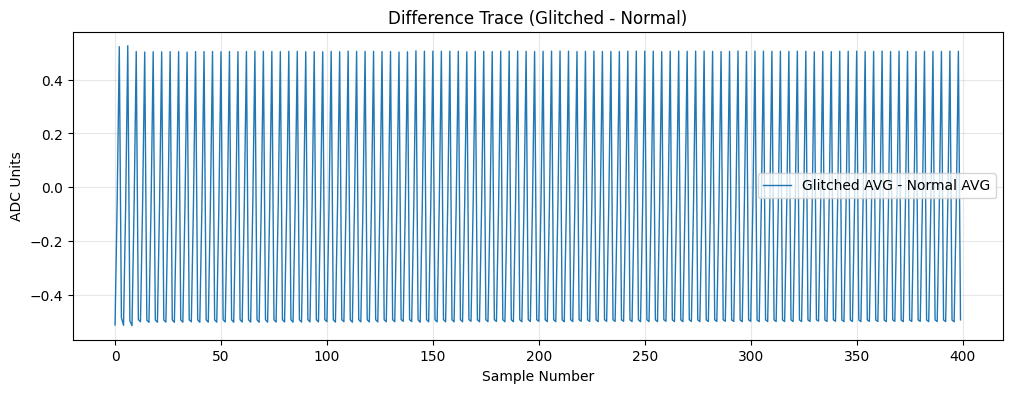

In [36]:
import numpy as np
import matplotlib.pyplot as plt

EXPECTED = bytes(EXPECTED_CIPHERTEXT)

# ---------- 1) Collect 10,000 GLITCHED traces ----------
def collect_glitched_traces(N=10000, verbose_every=500):
    glitched_traces = []
    normals = 0
    faults = 0
    timeouts = 0
    bad_reads = 0

    for i in range(N):
        scope.arm()
        out, ok = run_aes(target, PLAINTEXT, KEY)

        if scope.capture():
            timeouts += 1
            continue

        if (not ok) or (out is None) or (len(out) != 16):
            bad_reads += 1
            continue

        trace = np.array(scope.get_last_trace(), dtype=np.float32)
        glitched_traces.append(trace)

        if bytes(out) == EXPECTED:
            normals += 1
        else:
            faults += 1

        if verbose_every and ((i+1) % verbose_every == 0):
            print(f"i={i+1}/{N}  collected={len(glitched_traces)}  normals={normals}  faults={faults}  timeouts={timeouts}  bad_reads={bad_reads}")

    print("\n--- Glitch collection done ---")
    print(f"Requested={N}, Collected={len(glitched_traces)}")
    print(f"Normals={normals}, Faults={faults}, Timeouts={timeouts}, BadReads={bad_reads}")
    return glitched_traces

# ✅ make sure glitch is ON before calling this:
# scope.io.glitch_lp = True
# scope.io.glitch_hp = False
# scope.glitch.trigger_src = 'ext_single'
# scope.glitch.width = ...
# scope.glitch.offset = ...

glitched_traces = collect_glitched_traces(N=10000, verbose_every=500)

if len(glitched_traces) == 0:
    raise RuntimeError("No glitched traces collected. Check trigger/glitch setup and try again.")

# ---------- 2) Compute averages ----------
normal_avg  = np.mean(np.asarray(normal_traces, dtype=np.float32), axis=0)
glitch_avg  = np.mean(np.asarray(glitched_traces, dtype=np.float32), axis=0)

normal_one  = np.array(normal_traces[0], dtype=np.float32)
glitch_one  = np.array(glitched_traces[0], dtype=np.float32)

# ---------- 3) Plot like your baseline (Normal) ----------
plt.figure(figsize=(12, 6))
plt.plot(normal_one, label="Normal Single (Trace 0)", alpha=0.5, linewidth=1)
plt.plot(normal_avg, label=f"Normal Average of {len(normal_traces)}", linewidth=1)
plt.title("Baseline Power Trace: AES on CW305 FPGA (Normal)")
plt.xlabel("Sample Number")
plt.ylabel("Power Consumption (ADC Units)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ---------- 4) Plot like your baseline (Glitched) ----------
plt.figure(figsize=(12, 6))
plt.plot(glitch_one, label="Glitched Single (Trace 0)", alpha=0.5, linewidth=1)
plt.plot(glitch_avg, label=f"Glitched Average of {len(glitched_traces)}", linewidth=1)
plt.title("Power Trace: AES on CW305 FPGA (Glitched Attempts)")
plt.xlabel("Sample Number")
plt.ylabel("Power Consumption (ADC Units)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ---------- 5) Compare averages on same plot ----------
plt.figure(figsize=(12, 6))
plt.plot(normal_avg, label="Normal AVG", linewidth=1)
plt.plot(glitch_avg, label="Glitched AVG", linewidth=1)
plt.title("Comparison: Normal AVG vs Glitched AVG")
plt.xlabel("Sample Number")
plt.ylabel("Power Consumption (ADC Units)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ---------- 6) Optional difference plot ----------
plt.figure(figsize=(12, 4))
plt.plot(glitch_avg - normal_avg, label="Glitched AVG - Normal AVG", linewidth=1)
plt.title("Difference Trace (Glitched - Normal)")
plt.xlabel("Sample Number")
plt.ylabel("ADC Units")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [38]:
print("ADC src:", scope.clock.adc_src)
print("Trigger:", scope.trigger.triggers)
print("Basic mode:", scope.adc.basic_mode)
print("Samples:", scope.adc.samples)


ADC src: extclk_x4
Trigger: tio4
Basic mode: falling_edge
Samples: 400
